In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'ML_Project',
 ' Survey on Incidence of Diabetes and Other Chronic Diseases – Focus on Cardiovascular Diseases and Hypertension .gform',
 ' Survey on Incidence of Diabetes and Other Chronic Diseases – Focus on Cardiovascular Diseases and Hypertension  (Responses).gsheet',
 'Untitled form.gform',
 'Untitled form (Responses).gsheet',
 'Copy of  Survey on Incidence of Diabetes and Other Chronic Diseases – Focus on Cardiovascular Diseases and Hypertension  (Responses).gsheet',
 'Copy of  Survey on Incidence of Diabetes and Other Chronic Diseases – Focus on Cardiovascular Diseases and Hypertension .gform',
 'IMG-20260111-WA0000.jpg',
 '6754edd6e760cb30d6753c4529a9e5a0.htm',
 'smartinternz certificate.png',
 'Ayesha_Siddikha_Resume-1.pdf',
 'GEMINI VIDEO.mp4']

In [ ]:
import os

os.listdir('/content/drive/MyDrive/ML_Project')

['customer_subscription_churn_usage_patterns.csv']

# Customer Churn Analysis

## Project Overview

This project analyzes customer churn behavior in a subscription-based service using Exploratory Data Analysis (EDA). The objective is to identify key factors associated with customer attrition and generate actionable business insights to improve customer retention. The analysis focuses on customer engagement, subscription behavior, payment performance, support interactions, and inactivity patterns.

## 1. Introduction
Customer churn is one of the most critical business challenges for subscription-based companies. This project analyzes customer subscription behavior to identify factors influencing churn and to uncover actionable insights that can improve customer retention strategies.


## 2. Dataset Overview
The dataset contains 2,800 customer subscription records, including subscription plans, usage behavior, payment activity, customer support interactions, tenure, and churn status.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Project/customer_subscription_churn_usage_patterns.csv')

df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,15-04-2023,Premium,699,1.1,4,1,8,14,Yes
1,2,27-08-2023,Premium,699,2.6,6,0,35,1,Yes
2,3,12-10-2023,Premium,699,14.3,8,3,2,14,Yes
3,4,11-12-2023,Basic,199,17.6,5,2,11,9,Yes
4,5,14-02-2023,Basic,199,9.8,5,2,6,38,Yes


## 3. Data Understanding

In [ ]:
df.shape

(2800, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


In [ ]:
df.isnull().sum()

,0
user_id,0
signup_date,0
plan_type,0
monthly_fee,0
avg_weekly_usage_hours,0
support_tickets,0
payment_failures,0
tenure_months,0
last_login_days_ago,0
churn,0


**Insight**: The dataset contains 2,800 records and 10 features with no missing values, making it suitable for reliable exploratory data analysis.

In [ ]:
df.describe()

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


**Insight**: Churn rates remain similar across all subscription plans (56–58%), suggesting that customer retention is influenced more by behavioral factors than by subscription type.



## 4. Exploratory Data Analysis (EDA)
### 4.1 Churn Distribution

In [ ]:
df['churn'].value_counts()

,count
churn,
Yes,1605
No,1195


**Insight**: Approximately 57% of customers have churned, indicating a significant retention challenge and highlighting the need to identify key churn drivers.

### 4.2 Churn by Subscription Plan

In [ ]:
pd.crosstab(df['plan_type'], df['churn'], normalize='index') * 100

churn,No,Yes
plan_type,,
Basic,42.145179,57.854821
Premium,41.949153,58.050847
Standard,43.944266,56.055734


**Insight**: Churn rates remain consistently high across all subscription plans, suggesting that pricing tiers alone are not enough to retain customers.

### 4.3 Usage Behavior Analysis

In [ ]:
df.groupby('churn')['avg_weekly_usage_hours'].mean()

,avg_weekly_usage_hours
churn,
No,13.746444
Yes,12.254829


**Insight**: Active customers spend more time on the platform (13.75 hrs/week) than churned customers (12.25 hrs/week), indicating that lower engagement may contribute to customer attrition.

### 4.4 Payment Failure Analysis

In [ ]:
df.groupby('churn')['payment_failures'].mean()

,payment_failures
churn,
No,2.072803
Yes,2.803738


**Insight**: Churned customers experience noticeably more payment failures, making payment issues one of the strongest warning signs of customer loss.

### 4.5 Tenure Analysis

In [ ]:
df.groupby('churn')['tenure_months'].mean()

,tenure_months
churn,
No,18.588285
Yes,18.631153


Insight:  Customer tenure shows almost no difference between churned and retained users, suggesting that churn is driven more by customer behavior than by how long they have been subscribed.

### 4.6 Last Login Analysis

In [ ]:
df.groupby('churn')['last_login_days_ago'].mean()

,last_login_days_ago
churn,
No,26.149791
Yes,32.875389


**Insight**: Customers who churn remain inactive for longer periods, averaging 32.9 days since their last login compared to 26.1 days for retained users. This highlights declining user activity as a strong early warning sign of customer churn.

### 4.7 Support Ticket Analysis

In [ ]:
df.groupby('churn')['support_tickets'].mean()

,support_tickets
churn,
No,3.435983
Yes,4.224299


**Insight**: Churned customers raise more support tickets on average (4.22 vs 3.44), suggesting that unresolved issues or poor customer experience may contribute significantly to customer churn.

## 5. Data Visualization
###5.1 Churn Distribution Count Plot

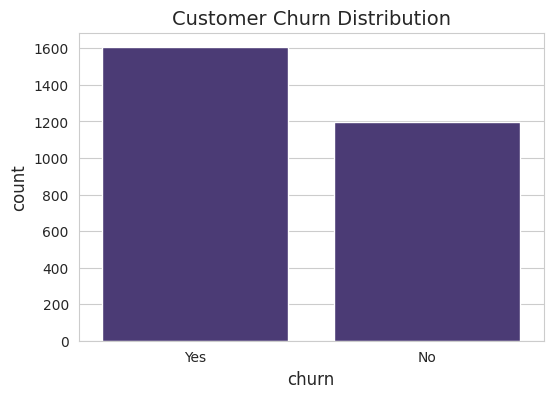

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
sns.set_palette("viridis")

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

 **Insight**: Churned customers constitute the majority of the customer base, with 57.3% of users leaving the service. This indicates a significant retention challenge and highlights the need to identify the key drivers behind customer attrition.

### 5.2 Churn Rate by Subscription Plan

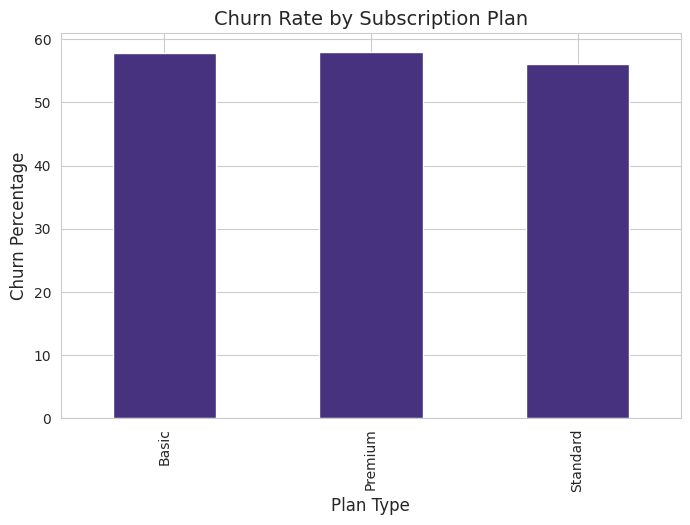

In [ ]:
plan_churn = pd.crosstab(df['plan_type'], df['churn'], normalize='index') * 100

plan_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Subscription Plan')
plt.ylabel('Churn Percentage')
plt.xlabel('Plan Type')
plt.show()

 **Insight**: Churn rates remain consistently high across all subscription plans (56–58%), suggesting that customer attrition is influenced more by user behavior and engagement factors than by subscription pricing alone.

### 5.3 Customer Usage Behavior by Churn Status

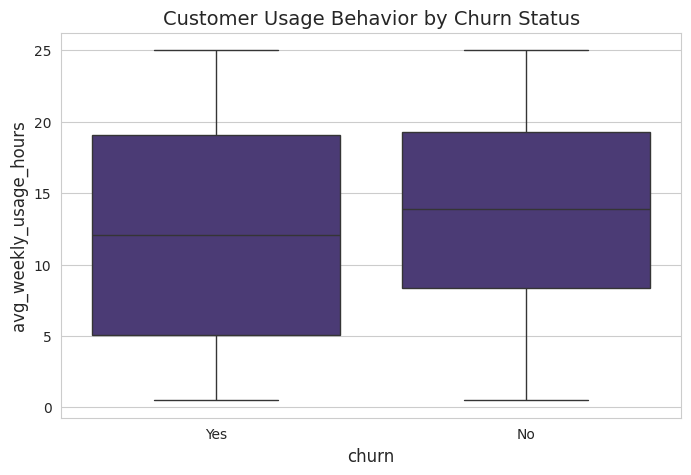

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='avg_weekly_usage_hours', data=df)
plt.title('Customer Usage Behavior by Churn Status')
plt.show()

 **Insight:** Customers who remained subscribed exhibited higher and more consistent usage patterns, suggesting that product engagement plays a key role in customer retention.

### 5.4 Payment Failures by Churn Status

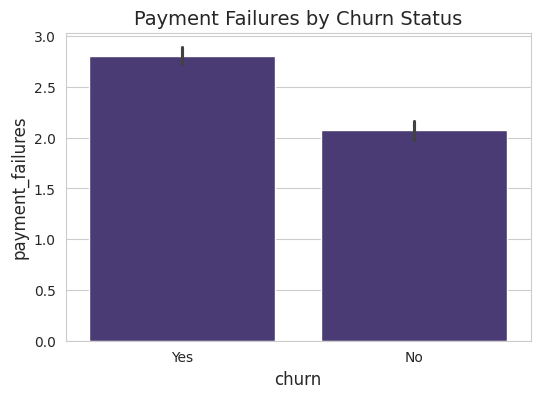

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='churn', y='payment_failures', data=df)
plt.title('Payment Failures by Churn Status')
plt.show()

**Insight**: Churned customers experienced significantly more payment failures than retained customers, indicating that payment issues are a major contributor to customer attrition.


### 5.5 Last Login Activity by Churn Status

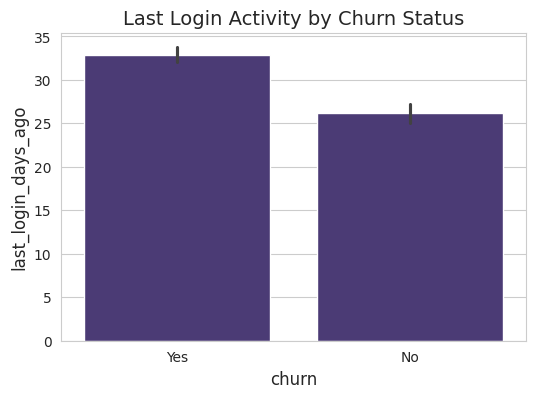

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='churn', y='last_login_days_ago', data=df)
plt.title('Last Login Activity by Churn Status')
plt.show()

**Insight**: Churned customers showed significantly longer periods of inactivity, indicating that declining engagement is a strong early warning sign of customer churn.

### 5.6 Support Tickets by Churn Status

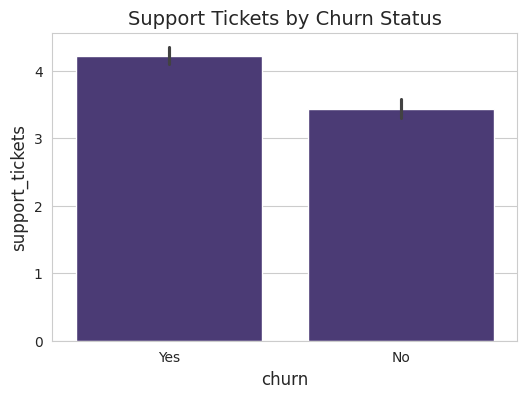

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='churn', y='support_tickets', data=df)
plt.title('Support Tickets by Churn Status')
plt.show()

**Insight**: Churned customers raised significantly more support tickets, indicating that frequent service issues and unresolved concerns may be key drivers of customer attrition.

## Customer Churn Risk Profile

High-Risk Customer Profile:

• Lower weekly product usage
• Higher payment failures
• Increased support ticket activity
• Longer periods of inactivity

These characteristics consistently appear among customers who churned, making them valuable indicators for early churn detection and retention planning.

## Churn Risk Scoring

In [ ]:
df['risk_score'] = 0

df['risk_score'] += (df['avg_weekly_usage_hours'] < 10).astype(int)

df['risk_score'] += (df['payment_failures'] > 3).astype(int)

df['risk_score'] += (df['support_tickets'] > 5).astype(int)

df['risk_score'] += (df['last_login_days_ago'] > 30).astype(int)

df['risk_score'].value_counts().sort_index()

,count
risk_score,
0,408
1,1008
2,965
3,368
4,51


**Insight**: Most customers fall into the medium-risk category (scores 1–2), while 419 customers (scores 3–4) exhibit multiple churn risk indicators and should be prioritized for retention efforts.

### Risk Score Distribution Analysis

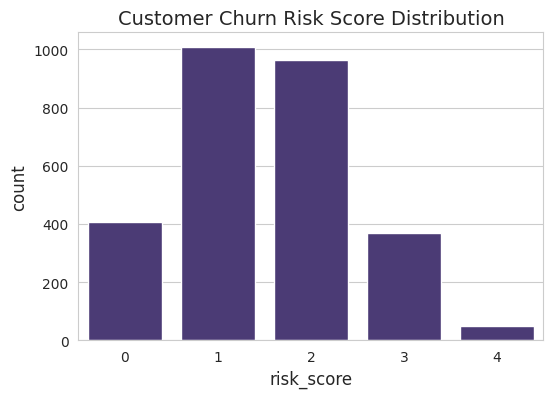

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='risk_score', data=df)
plt.title('Customer Churn Risk Score Distribution')
plt.show()

**Insight**: The risk scoring model identifies a significant group of customers with elevated churn risk, enabling businesses to focus retention strategies on the most vulnerable customer segments.

## Key Findings

🔹 Customer churn is high, with 57.3% of subscribers leaving the service.

🔹 Subscription plan type has minimal influence on churn, indicating that customer behavior is more important than pricing tier.

🔹 Lower product usage is consistently associated with higher churn probability.

🔹 Payment failures emerged as one of the strongest operational indicators of customer attrition.

🔹 Churned customers showed longer inactivity periods and higher support ticket volumes compared to active customers.

🔹 The churn risk scoring model identified 419 customers in high-risk segments (Risk Scores 3–4), highlighting opportunities for proactive retention strategies.

## Business Recommendations

✔ Launch targeted engagement campaigns for low-usage customers.

✔ Implement automated payment reminders and recovery workflows to reduce payment failures.

✔ Monitor customer inactivity and trigger retention campaigns before churn occurs.

✔ Improve customer support resolution quality for users with frequent support interactions.

✔ Prioritize customers with Risk Scores 3–4 for personalized retention programs.

✔ Develop a machine learning-based churn prediction system to identify at-risk customers earlier and improve customer lifetime value.

## Skills Demonstrated

✔ Data Cleaning and Validation

✔ Exploratory Data Analysis (EDA)

✔ Data Visualization using Seaborn and Matplotlib

✔ Business Insight Generation

✔ Customer Segmentation and Risk Analysis

✔ Churn Risk Scoring

✔ Data-Driven Decision Making

## Conclusion

This project analyzed customer churn behavior using subscription, engagement, payment, and support-related data. The analysis revealed that customer behavior factors such as low product usage, payment failures, prolonged inactivity, and increased support interactions are strongly associated with customer churn.

A churn risk scoring framework was also developed to identify high-risk customers and support proactive retention strategies. The findings provide actionable business insights that can help subscription-based organizations improve customer retention and reduce revenue loss.

**The results demonstrate how data analytics can transform customer behavior data into strategic business decisions and serve as a foundation for future machine learning-based churn prediction models.**

# Machine Learning Model for Churn Prediction

## Data Preparation for Machine Learning

In [ ]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

df['churn'].head()

,churn
0,1
1,1
2,1
3,1
4,1


**Insight:** The target variable was successfully converted into numerical format, where 1 represents churned customers and 0 represents active customers, making the dataset ready for machine learning model training.

##Feature Encoding

In [ ]:
df = pd.get_dummies(df, columns=['plan_type'], drop_first=True)

df.head()

,user_id,signup_date,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,plan_type_Premium,plan_type_Standard
0,1,15-04-2023,699,1.1,4,1,8,14,1,True,False
1,2,27-08-2023,699,2.6,6,0,35,1,1,True,False
2,3,12-10-2023,699,14.3,8,3,2,14,1,True,False
3,4,11-12-2023,199,17.6,5,2,11,9,1,False,False
4,5,14-02-2023,199,9.8,5,2,6,38,1,False,False


**Insight:** The categorical subscription plan feature was converted into numerical variables using one-hot encoding, enabling machine learning algorithms to process subscription plan information effectively.

## Feature Selection

In [ ]:
X = df[['monthly_fee',
        'avg_weekly_usage_hours',
        'support_tickets',
        'payment_failures',
        'tenure_months',
        'last_login_days_ago',
        'plan_type_Premium',
        'plan_type_Standard']]

y = df['churn']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2800, 8)
Target Shape: (2800,)


## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2240, 8)
Testing Data: (560, 8)


## Logistic Regression Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


**Insight:** A Logistic Regression model was trained to learn customer churn patterns and predict whether a customer is likely to leave the service.

## Model Prediction

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 0 1 1 1 1 0 1 1]


## Model Accuracy Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 65.36 %


**Insight:** The Logistic Regression model achieved an accuracy of 65.36%, demonstrating a moderate ability to predict customer churn patterns. Further improvements may be achieved through feature engineering and advanced machine learning algorithms such as Random Forest and XGBoost.

## Confusion Matrix

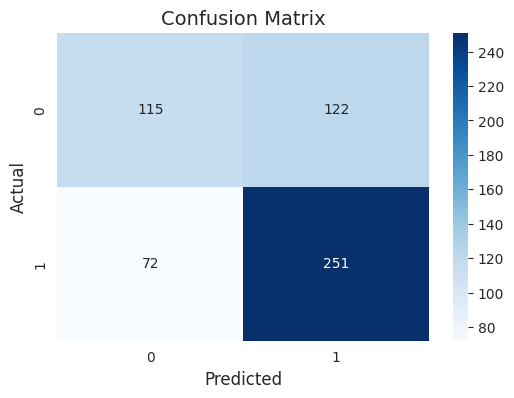

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Insight:** The model correctly identified 251 churned customers and 115 active customers. While prediction performance is moderate, the model demonstrates the ability to detect churn patterns and can be further improved using advanced machine learning techniques.

## Classification Report

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.49      0.54       237
           1       0.67      0.78      0.72       323

    accuracy                           0.65       560
   macro avg       0.64      0.63      0.63       560
weighted avg       0.65      0.65      0.65       560



**Insight:** The model achieved a balanced performance with an overall accuracy of 65.36%. It demonstrated stronger capability in identifying churned customers (Recall = 0.78) compared to active customers, making it useful for early churn detection and customer retention initiatives.

## Feature Importance Analysis

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient
3,payment_failures,0.286179
2,support_tickets,0.143223
6,plan_type_Premium,0.037068
5,last_login_days_ago,0.025599
0,monthly_fee,0.000088
4,tenure_months,-0.000248
1,avg_weekly_usage_hours,-0.034333
7,plan_type_Standard,-0.093179


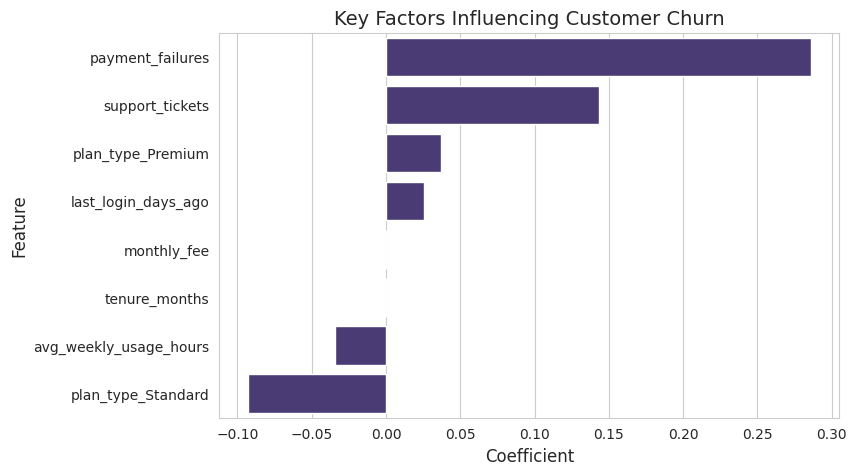

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance
)

plt.title('Key Factors Influencing Customer Churn')
plt.show()

**Insight:** Payment failures and support ticket volume emerged as the strongest predictors of customer churn, while higher user engagement and Standard plan subscriptions were associated with improved customer retention.